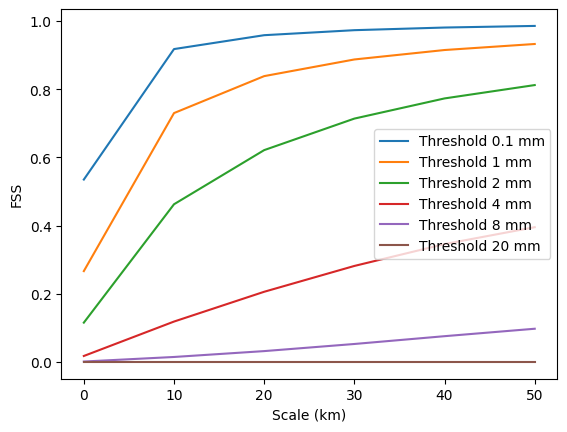

In [3]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pysteps.verification.spatialscores import fss

# 加载数据集
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex61_onestepdiffusion_dividemax_minmaxnormlazie_timesteps250_l2_droptop_0.5_150epoch/corrected_prcp_downs_global.nc")

# 提取数据
y_pred_np = ds['fcst_corrected'].values
tar_np = ds['hr'].values

tar_np = tar_np.reshape(tar_np.shape[1],-1)
y_pred_np = y_pred_np.reshape(y_pred_np.shape[1],-1)

# 定义阈值和scales
thresholds = [0.1, 1, 2, 4, 8, 20]
radii = [0, 10, 20, 30, 40, 50]

# 计算FSS
fss_scores = {thresh: [] for thresh in thresholds}
for radius in radii:
    for thresh in thresholds:
        fss_value = fss(y_pred_np, tar_np, thresh, scale=radius)
        fss_scores[thresh].append(fss_value)

# 绘图
fig, ax = plt.subplots()
for thresh in thresholds:
    ax.plot(radii, fss_scores[thresh], label=f'Threshold {thresh} mm')
ax.set_xlabel('Scale (km)')
ax.set_ylabel('FSS')
ax.legend()
plt.show()

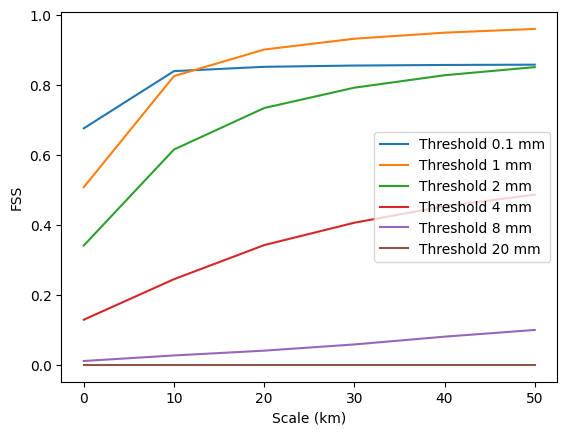

In [3]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pysteps.verification.spatialscores import fss

# 加载数据集
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex4_onestep_weightmae_0.005/prcp_downs_unet_year_2020.nc")

# 提取数据
y_pred_np = ds['inter'].values
tar_np = ds['hr'].values

tar_np = tar_np.reshape(tar_np.shape[1],-1)
y_pred_np = y_pred_np.reshape(y_pred_np.shape[1],-1)

# 定义阈值和scales
thresholds = [0.1, 1, 2, 4, 8, 20]
radii = [0, 10, 20, 30, 40, 50]

# 计算FSS
fss_scores = {thresh: [] for thresh in thresholds}
for radius in radii:
    for thresh in thresholds:
        fss_value = fss(y_pred_np, tar_np, thresh, scale=radius)
        fss_scores[thresh].append(fss_value)

# 绘图
fig, ax = plt.subplots()
for thresh in thresholds:
    ax.plot(radii, fss_scores[thresh], label=f'Threshold {thresh} mm')
ax.set_xlabel('Scale (km)')
ax.set_ylabel('FSS')
ax.legend()
plt.show()